In [1]:
from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Generalizable-DDA-RL

Mounted at /content/drive
/content/drive/MyDrive/Generalizable-DDA-RL


## ***Imports***

In [2]:
!pip install -q stable-baselines3 gymnasium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.7 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Load Existing Environment***

In [3]:
from src.environment import GADDAEnv

In [4]:
env = GADDAEnv()

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box(0.0, 1.0, (5,), float32)
Action space: Box(0.0, 1.0, (1,), float32)


### ***Create the No-Uncertainity Observation Wrapper***

In [5]:
class RemoveUncertainty(ObservationWrapper):
    """
    Removes the uncertainty feature from the observation.

    Original:
    [estimated_skill,
     uncertainty,
     recent_win_rate,
     recent_error_rate,
     normalized_step]

    New:
    [estimated_skill,
     recent_win_rate,
     recent_error_rate,
     normalized_step]
    """

    def __init__(self, env):
        super().__init__(env)

        low = np.delete(
            self.observation_space.low,
            1
        )

        high = np.delete(
            self.observation_space.high,
            1
        )

        self.observation_space = Box(
            low=low,
            high=high,
            dtype=np.float32
        )

    def observation(self, observation):
        return np.delete(
            observation,
            1
        ).astype(np.float32)

### ***Verify It***

In [6]:
base_env = GADDAEnv()

ablation_env = RemoveUncertainty(
    base_env
)

print(
    "Original observation:",
    base_env.observation_space
)

print(
    "Ablation observation:",
    ablation_env.observation_space
)

Original observation: Box(0.0, 1.0, (5,), float32)
Ablation observation: Box(0.0, 1.0, (4,), float32)


In [7]:
obs, info = ablation_env.reset(seed=42)

print("Ablation observation:", obs)
print("Shape:", obs.shape)

Ablation observation: [0.5 0.5 0.7 0.5]
Shape: (4,)


### ***Train the Ablation PPO***



In [8]:
ablation_model = PPO(
    "MlpPolicy",
    ablation_env,
    learning_rate=0.0003,
    verbose=1,
    device="cpu",
    seed=42
)

ablation_model.learn(
    total_timesteps=100000
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 148      |
| time/              |          |
|    fps             | 823      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | 149          |
| time/                   |              |
|    fps                  | 677          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044042883 |
|    clip_fraction        | 0.0612       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.00333      |
|    learning_rate        | 0.0003       |
|    loss                 | 8.96         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00701     |
|    std                  | 1            |
|    value_loss           | 61.1         |
------------------------------------------
------------------------------------------
| rollout/ 

In [9]:
ablation_model.save(
    "models/ppo_no_uncertainty"
)

### ***Basic Evaluation***





In [10]:
obs, info = ablation_env.reset(seed=100)

total_reward = 0

for step in range(200):

    action, _ = ablation_model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = (
        ablation_env.step(action)
    )

    total_reward += reward

    if terminated or truncated:
        break

print("Total reward:", total_reward)
print("Steps:", step + 1)

Total reward: 205.14684429032425
Steps: 200


### ***Save Ablation Model***

In [11]:
ablation_model.save("models/ppo_no_uncertainty")
print("Model saved successfully")

Model saved successfully


### ***Verify Saved Model***

In [12]:
import os

model_path = "models/ppo_no_uncertainty.zip"

print("Model exists:", os.path.exists(model_path))
print("Model path:", model_path)

Model exists: True
Model path: models/ppo_no_uncertainty.zip


### ***Uncertainity Ablation Evaluation Setup***

In [13]:
import numpy as np
import pandas as pd

UNSEEN_PLAYER_PROFILES = {
    "Unseen Low Skill": {
        "initial_skill": 0.15,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    "Unseen High Skill": {
        "initial_skill": 0.90,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    "Unseen Fast Learning": {
        "initial_skill": 0.20,
        "learning_rate": 0.006,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    "Unseen Strong Fatigue": {
        "initial_skill": 0.90,
        "learning_rate": 0.0,
        "fatigue_rate": 0.005,
        "noise_std": 0.05
    },
    "Unseen High Noise": {
        "initial_skill": 0.30,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.20
    }
}

GENERALIZATION_SEEDS = list(range(100, 110))

print("Profiles:", len(UNSEEN_PLAYER_PROFILES))
print("Seeds:", len(GENERALIZATION_SEEDS))
print("Total evaluation episodes:",
      len(UNSEEN_PLAYER_PROFILES) * len(GENERALIZATION_SEEDS))

Profiles: 5
Seeds: 10
Total evaluation episodes: 50


### ***Evaluate PPO without uncertainity***

In [14]:
from src.environment import GADDAEnv

TARGET_WIN_RATE = 0.70
MAX_STEPS = 200

ablation_results = []

for profile_name, player_config in UNSEEN_PLAYER_PROFILES.items():

    for seed in GENERALIZATION_SEEDS:

        # Create base environment with the held-out player
        base_env = GADDAEnv(
            max_steps=MAX_STEPS,
            target_win_rate=TARGET_WIN_RATE,
            player_config=player_config,
            seed=seed
        )

        # Remove uncertainty from observations
        env = RemoveUncertainty(base_env)

        obs, info = env.reset(seed=seed)

        total_reward = 0.0
        trajectory = []

        for step in range(MAX_STEPS):

            action, _ = ablation_model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            trajectory.append({
                "Difficulty": info["difficulty"],
                "Recent Win Rate": info["recent_win_rate"],
                "Error Rate": info["error_rate"],
                "Reward": reward
            })

            if terminated or truncated:
                break

        trajectory_df = pd.DataFrame(trajectory)

        mean_win_rate = trajectory_df["Recent Win Rate"].mean()
        final_rolling_win_rate = trajectory_df["Recent Win Rate"].iloc[-1]

        win_rate_error = abs(
            mean_win_rate - TARGET_WIN_RATE
        )

        difficulty_std = trajectory_df["Difficulty"].std()

        difficulty_changes = trajectory_df["Difficulty"].diff().dropna()

        mean_abs_difficulty_change = (
            difficulty_changes.abs().mean()
        )

        ablation_results.append({
            "Method": "PPO No Uncertainty",
            "Profile": profile_name,
            "Seed": seed,
            "Total Reward": total_reward,
            "Final Rolling Win Rate": final_rolling_win_rate,
            "Mean Win Rate": mean_win_rate,
            "Win Rate Error": win_rate_error,
            "Difficulty Std": difficulty_std,
            "Mean Absolute Difficulty Change":
                mean_abs_difficulty_change,
            "Episode Length": len(trajectory_df)
        })

        env.close()

ablation_results_df = pd.DataFrame(ablation_results)

print("Evaluation completed.")
print("Number of runs:", len(ablation_results_df))
print()
print(ablation_results_df.head())

Evaluation completed.
Number of runs: 50

               Method           Profile  Seed  Total Reward  \
0  PPO No Uncertainty  Unseen Low Skill   100    -43.052826   
1  PPO No Uncertainty  Unseen Low Skill   101     -6.249799   
2  PPO No Uncertainty  Unseen Low Skill   102    -39.475655   
3  PPO No Uncertainty  Unseen Low Skill   103    -20.262997   
4  PPO No Uncertainty  Unseen Low Skill   104    -50.267065   

   Final Rolling Win Rate  Mean Win Rate  Win Rate Error  Difficulty Std  \
0                     0.3       0.330101        0.369899        0.073026   
1                     0.3       0.366601        0.333399        0.077485   
2                     0.2       0.336012        0.363988        0.071681   
3                     0.5       0.351381        0.348619        0.071123   
4                     0.5       0.324359        0.375641        0.070553   

   Mean Absolute Difficulty Change  Episode Length  
0                         0.062164             200  
1               

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Profile Level Ablation Summary***

In [15]:
profile_summary = (
    ablation_results_df
    .groupby("Profile")
    .agg(
        Mean_Win_Rate_Error=("Win Rate Error", "mean"),
        Std_Win_Rate_Error=("Win Rate Error", "std"),
        Mean_Total_Reward=("Total Reward", "mean"),
        Mean_Final_Win_Rate=("Final Rolling Win Rate", "mean"),
        Mean_Difficulty_Std=("Difficulty Std", "mean"),
        Mean_Abs_Difficulty_Change=(
            "Mean Absolute Difficulty Change", "mean"
        )
    )
    .reset_index()
)

profile_summary = profile_summary.sort_values(
    "Mean_Win_Rate_Error"
)

print(profile_summary.to_string(index=False))

              Profile  Mean_Win_Rate_Error  Std_Win_Rate_Error  Mean_Total_Reward  Mean_Final_Win_Rate  Mean_Difficulty_Std  Mean_Abs_Difficulty_Change
 Unseen Fast Learning             0.091547            0.021212         136.049882                 0.95             0.141282                    0.048201
Unseen Strong Fatigue             0.109861            0.021827          83.583297                 0.29             0.139334                    0.058225
    Unseen High Noise             0.206837            0.027976         106.178996                 0.52             0.076019                    0.063805
    Unseen High Skill             0.215789            0.010034         115.274342                 0.93             0.108610                    0.042227
     Unseen Low Skill             0.350639            0.017071         -24.220171                 0.34             0.073667                    0.063846


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Overall Ablation Summary***

In [16]:
overall_ablation = ablation_results_df.agg({
    "Win Rate Error": ["mean", "std"],
    "Total Reward": ["mean", "std"],
    "Final Rolling Win Rate": ["mean", "std"],
    "Difficulty Std": ["mean", "std"],
    "Mean Absolute Difficulty Change": ["mean", "std"]
})

print(overall_ablation)

      Win Rate Error  Total Reward  Final Rolling Win Rate  Difficulty Std  \
mean        0.194935     83.373269                0.606000        0.107783   
std         0.095445     58.808513                0.294445        0.030130   

      Mean Absolute Difficulty Change  
mean                         0.055261  
std                          0.008971  


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Check available result files***

In [17]:
import os

for root, dirs, files in os.walk("results"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

results/evaluation_raw_results.csv
results/evaluation_summary.csv
results/Table_1_Main_Results.csv
results/Table_2_PPO_vs_Baselines.csv
results/Table_3_Statistical_Results.csv
results/overall_statistics.csv
results/mean_std_results.csv
results/profile_statistics.csv
results/ppo_vs_baselines.csv
results/statistical_tests.csv
results/effect_sizes.csv
results/final_method_ranking.csv
results/tables/baseline_results.csv
results/tables/final_paired_statistical_results.csv
results/generalization/trajectories/generalization_trajectories.csv
results/generalization/tables/unseen_player_profiles.csv
results/generalization/tables/generalization_raw_results.csv
results/generalization/tables/generalization_paired_statistics.csv
results/generalization/tables/generalization_profile_results.csv
results/generalization/tables/generalization_profile_improvements.csv
results/generalization/tables/generalization_summary.csv


### ***Load Original PPO Generalisation Results***

In [18]:
ppo_generalization_df = pd.read_csv(
    "results/generalization/tables/generalization_raw_results.csv"
)

print("Rows:", len(ppo_generalization_df))
print("Columns:")
print(ppo_generalization_df.columns.tolist())

print("\nFirst 5 rows:")
display(ppo_generalization_df.head())

Rows: 250
Columns:
['Method', 'Total Reward', 'Final Win Rate', 'Mean Rolling Win Rate', 'Win Rate Error', 'Mean Difficulty', 'Difficulty Std', 'Mean Absolute Difficulty Change', 'Episode Length', 'Player Profile', 'Seed']

First 5 rows:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Method,Total Reward,Final Win Rate,Mean Rolling Win Rate,Win Rate Error,Mean Difficulty,Difficulty Std,Mean Absolute Difficulty Change,Episode Length,Player Profile,Seed
0,PPO DDA,158.532639,0.6,0.565052,0.134948,0.092141,0.183546,0.112068,200,Unseen Low Skill,100
1,Static Easy,-216.535535,0.3,0.210101,0.489899,0.300000,0.000000,0.000000,200,Unseen Low Skill,100
2,Static Medium,-444.592256,0.1,0.075145,0.624855,0.500000,0.000000,0.000000,200,Unseen Low Skill,100
3,Static Hard,-538.120549,0.0,0.030145,0.669855,0.700000,0.000000,0.000000,200,Unseen Low Skill,100
4,Rule-Based DDA,150.204732,0.9,0.718873,0.018873,0.011250,0.058764,0.002261,200,Unseen Low Skill,100


### ***Extract Original PPO Runs***

In [19]:
ppo_original = ppo_generalization_df[
    ppo_generalization_df["Method"] == "PPO DDA"
].copy()

# Rename only for matching with the ablation dataframe
ppo_original = ppo_original.rename(
    columns={"Player Profile": "Profile"}
)

print("Original PPO runs:", len(ppo_original))

print("\nUnique profiles:")
print(ppo_original["Profile"].unique())

print("\nSeeds:")
print(sorted(ppo_original["Seed"].unique()))

print("\nMissing values:")
print(ppo_original[["Profile", "Seed", "Win Rate Error"]]
      .isna()
      .sum())

Original PPO runs: 50

Unique profiles:
['Unseen Low Skill' 'Unseen High Skill' 'Unseen Fast Learning'
 'Unseen Strong Fatigue' 'Unseen High Noise']

Seeds:
[np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]

Missing values:
Profile           0
Seed              0
Win Rate Error    0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Create the Paired Ablation Dataset***

In [20]:
comparison_df = ppo_original[
    ["Profile", "Seed", "Win Rate Error"]
].rename(
    columns={"Win Rate Error": "Full PPO Error"}
)

ablation_compare = ablation_results_df[
    ["Profile", "Seed", "Win Rate Error"]
].rename(
    columns={"Win Rate Error": "No Uncertainty Error"}
)

paired_df = comparison_df.merge(
    ablation_compare,
    on=["Profile", "Seed"],
    how="inner",
    validate="one_to_one"
)

# Difference: positive means full PPO had lower error
paired_df["Error Increase Without Uncertainty"] = (
    paired_df["No Uncertainty Error"]
    - paired_df["Full PPO Error"]
)

print("Matched runs:", len(paired_df))

display(paired_df.head(10))

Matched runs: 50


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Profile,Seed,Full PPO Error,No Uncertainty Error,Error Increase Without Uncertainty
0,Unseen Low Skill,100,0.134948,0.369899,0.234950
1,Unseen Low Skill,101,0.115663,0.333399,0.217736
2,Unseen Low Skill,102,0.118093,0.363988,0.245895
3,Unseen Low Skill,103,0.112619,0.348619,0.236000
4,Unseen Low Skill,104,0.113913,0.375641,0.261728
5,Unseen Low Skill,105,0.126496,0.356232,0.229736
6,Unseen Low Skill,106,0.098464,0.325254,0.226790
7,Unseen Low Skill,107,0.157177,0.347677,0.190500
8,Unseen Low Skill,108,0.093135,0.329780,0.236645
9,Unseen Low Skill,109,0.145405,0.355905,0.210500


### ***Paired Statistical Test***

In [21]:
from scipy.stats import ttest_rel

full_error = paired_df["Full PPO Error"]
no_uncertainty_error = paired_df["No Uncertainty Error"]

t_stat, p_value = ttest_rel(
    full_error,
    no_uncertainty_error
)

# Mean paired difference
mean_difference = (
    no_uncertainty_error - full_error
).mean()

std_difference = (
    no_uncertainty_error - full_error
).std(ddof=1)

# 95% confidence interval
n = len(paired_df)
se = std_difference / np.sqrt(n)

from scipy.stats import t

t_critical = t.ppf(
    0.975,
    df=n - 1
)

ci_lower = mean_difference - t_critical * se
ci_upper = mean_difference + t_critical * se

# Paired Cohen's d
cohens_d = mean_difference / std_difference

print("Paired Ablation Test")
print("--------------------")
print(f"N: {n}")
print(f"Full PPO mean error: {full_error.mean():.6f}")
print(f"No-Uncertainty mean error: {no_uncertainty_error.mean():.6f}")
print(f"Mean error increase: {mean_difference:.6f}")
print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"t-statistic: {t_stat:.6f}")
print(f"p-value: {p_value:.10e}")
print(f"Paired Cohen's d: {cohens_d:.6f}")

Paired Ablation Test
--------------------
N: 50
Full PPO mean error: 0.080002
No-Uncertainty mean error: 0.194935
Mean error increase: 0.114933
95% CI: [0.094049, 0.135817]
t-statistic: -11.059405
p-value: 6.4052536045e-15
Paired Cohen's d: 1.564036


### ***Ablation Percentage Change***

In [22]:
full_mean = paired_df["Full PPO Error"].mean()
no_uncertainty_mean = paired_df["No Uncertainty Error"].mean()

error_increase_percent = (
    (no_uncertainty_mean - full_mean)
    / full_mean
) * 100

error_reduction_with_uncertainty = (
    (no_uncertainty_mean - full_mean)
    / no_uncertainty_mean
) * 100

print("Ablation Effect")
print("----------------")
print(f"Full PPO mean error: {full_mean:.6f}")
print(f"No-Uncertainty mean error: {no_uncertainty_mean:.6f}")
print(f"Error increase without uncertainty: {error_increase_percent:.2f}%")
print(
    f"Error reduction with uncertainty: "
    f"{error_reduction_with_uncertainty:.2f}%"
)

Ablation Effect
----------------
Full PPO mean error: 0.080002
No-Uncertainty mean error: 0.194935
Error increase without uncertainty: 143.66%
Error reduction with uncertainty: 58.96%


### ***Profile-wise Full PPO vs No-Uncertainity***

In [23]:
profile_ablation = (
    paired_df
    .groupby("Profile")
    .agg(
        Full_PPO_Error=("Full PPO Error", "mean"),
        No_Uncertainty_Error=("No Uncertainty Error", "mean"),
        Mean_Error_Increase=(
            "Error Increase Without Uncertainty", "mean"
        )
    )
    .reset_index()
)

profile_ablation["Error_Increase_Percent"] = (
    profile_ablation["Mean_Error_Increase"]
    / profile_ablation["Full_PPO_Error"]
) * 100

profile_ablation = profile_ablation.sort_values(
    "Full_PPO_Error"
)

display(profile_ablation)

,Profile,Full_PPO_Error,No_Uncertainty_Error,Mean_Error_Increase,Error_Increase_Percent
4,Unseen Strong Fatigue,0.026916,0.109861,0.082944,308.157278
1,Unseen High Noise,0.052476,0.206837,0.154362,294.159417
0,Unseen Fast Learning,0.070692,0.091547,0.020855,29.501497
3,Unseen Low Skill,0.121591,0.350639,0.229048,188.375379
2,Unseen High Skill,0.128334,0.215789,0.087456,68.146975


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Per-Profile Paired Tests***

In [24]:
from scipy.stats import ttest_rel

profile_tests = []

for profile, group in paired_df.groupby("Profile"):

    full = group["Full PPO Error"]
    no_unc = group["No Uncertainty Error"]

    t_stat, p_value = ttest_rel(full, no_unc)

    difference = no_unc - full
    mean_diff = difference.mean()
    std_diff = difference.std(ddof=1)

    cohens_d = mean_diff / std_diff

    profile_tests.append({
        "Profile": profile,
        "N": len(group),
        "Full PPO Error": full.mean(),
        "No Uncertainty Error": no_unc.mean(),
        "Mean Error Increase": mean_diff,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Paired Cohen's d": cohens_d
    })

profile_tests_df = pd.DataFrame(profile_tests)

display(profile_tests_df)

,Profile,N,Full PPO Error,No Uncertainty Error,Mean Error Increase,t-statistic,p-value,Paired Cohen's d
0,Unseen Fast Learning,10,0.070692,0.091547,0.020855,-4.734718,1.066808e-03,1.497249
1,Unseen High Noise,10,0.052476,0.206837,0.154362,-27.038933,6.269394e-10,8.550461
2,Unseen High Skill,10,0.128334,0.215789,0.087456,-27.308962,5.738654e-10,8.635852
3,Unseen Low Skill,10,0.121591,0.350639,0.229048,-36.961398,3.850071e-11,11.688220
4,Unseen Strong Fatigue,10,0.026916,0.109861,0.082944,-13.329507,3.131292e-07,4.215160


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Ablation Comparison Figure***

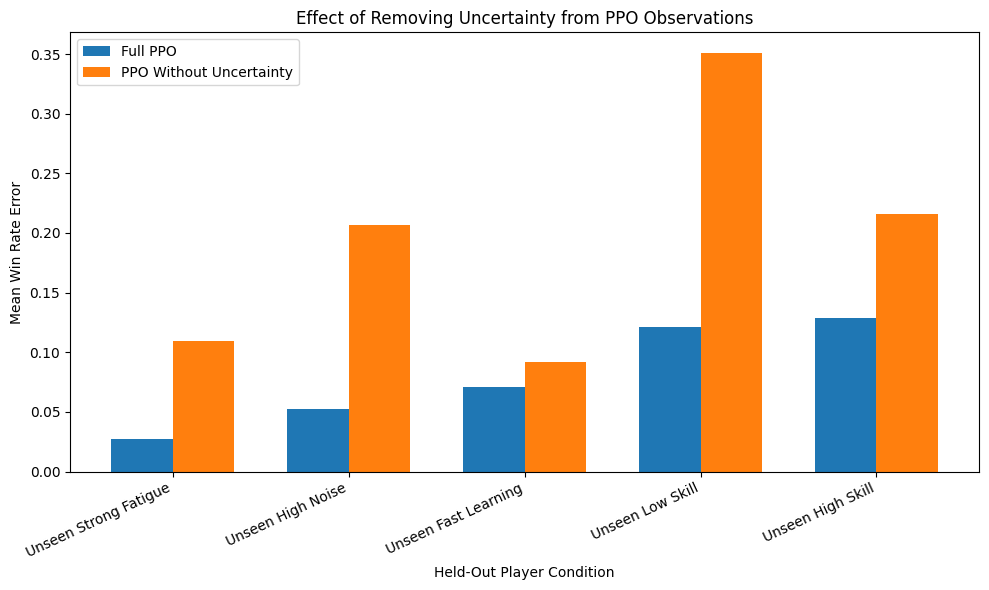

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
import matplotlib.pyplot as plt

plot_df = profile_ablation.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    plot_df["Full_PPO_Error"],
    width,
    label="Full PPO"
)

plt.bar(
    x + width/2,
    plot_df["No_Uncertainty_Error"],
    width,
    label="PPO Without Uncertainty"
)

plt.xticks(
    x,
    plot_df["Profile"],
    rotation=25,
    ha="right"
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Held-Out Player Condition")
plt.title("Effect of Removing Uncertainty from PPO Observations")
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/ablation_uncertainty_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Save Ablation Results***

In [27]:
import os

os.makedirs("results/ablation", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Raw 50-run ablation results
ablation_results_df.to_csv(
    "results/ablation/uncertainty_ablation_raw_results.csv",
    index=False
)

# Profile-level summary
profile_ablation.to_csv(
    "results/ablation/uncertainty_ablation_profile_summary.csv",
    index=False
)

# Profile-level statistical tests
profile_tests_df.to_csv(
    "results/ablation/uncertainty_ablation_profile_statistics.csv",
    index=False
)

# Matched Full PPO vs No-Uncertainty runs
paired_df.to_csv(
    "results/ablation/uncertainty_ablation_paired_results.csv",
    index=False
)

print("Ablation results saved :)")

Ablation results saved :)


### *Final Uncertainity Ablation Table*

In [28]:
final_ablation_table = pd.DataFrame({
    "Metric": [
        "Mean Win Rate Error",
        "Mean Total Reward",
        "Mean Final Rolling Win Rate",
        "Mean Difficulty Std",
        "Mean Absolute Difficulty Change"
    ],
    "Full PPO": [
        paired_df["Full PPO Error"].mean(),
        ppo_original["Total Reward"].mean(),
        ppo_original["Final Win Rate"].mean(),
        ppo_original["Difficulty Std"].mean(),
        ppo_original["Mean Absolute Difficulty Change"].mean()
    ],
    "PPO Without Uncertainty": [
        paired_df["No Uncertainty Error"].mean(),
        ablation_results_df["Total Reward"].mean(),
        ablation_results_df["Final Rolling Win Rate"].mean(),
        ablation_results_df["Difficulty Std"].mean(),
        ablation_results_df[
            "Mean Absolute Difficulty Change"
        ].mean()
    ]
})

display(final_ablation_table)

,Metric,Full PPO,PPO Without Uncertainty
0,Mean Win Rate Error,0.080002,0.194935
1,Mean Total Reward,179.244294,83.373269
2,Mean Final Rolling Win Rate,0.708000,0.606000
3,Mean Difficulty Std,0.305208,0.107783
4,Mean Absolute Difficulty Change,0.212795,0.055261


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Statistical Result Summary***

In [29]:
statistical_summary = pd.DataFrame({
    "Statistic": [
        "Matched evaluation runs",
        "Mean error increase",
        "95% CI lower",
        "95% CI upper",
        "t-statistic",
        "p-value",
        "Paired Cohen's d"
    ],
    "Value": [
        len(paired_df),
        mean_difference,
        ci_lower,
        ci_upper,
        t_stat,
        p_value,
        cohens_d
    ]
})

display(statistical_summary)

,Statistic,Value
0,Matched evaluation runs,5.000000e+01
1,Mean error increase,1.149330e-01
2,95% CI lower,9.404884e-02
3,95% CI upper,1.358172e-01
4,t-statistic,-1.332951e+01
5,p-value,3.131292e-07
6,Paired Cohen's d,4.215160e+00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Save Ablation Table***

In [30]:
final_ablation_table.to_csv(
    "results/ablation/uncertainty_ablation_final_table.csv",
    index=False
)

statistical_summary.to_csv(
    "results/ablation/uncertainty_ablation_statistical_summary.csv",
    index=False
)

print("Final Ablation Tables Saved :)")

Final Ablation Tables Saved :)
